# 60日动量因子 (中长期动量) 五分组回测框架
该 Notebook 实现了基于 60 日动量因子的逐日撮合回测。

**动量因子公式：**
`Factor = (Close / Close.shift(60)) - 1`
物理意义：买入过去 60 个交易日累计涨幅最大的股票（强者恒强）。
相比于短期量价因子，中长期动量因子的排名变化较慢，能有效降低换手率和交易摩擦成本。

**主要逻辑：**
1. 加载全市场数据并计算前向收益（1d, 1w, 1m）。
2. 计算 60日动量 因子，并按周调仓分为 5 组。
3. 各组分别买入得分最高的 10 只股票，统计净值曲线与前向收益。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_CSV = r"F:\self_quant\quant_gemini\csv\momentum_60d_trades_每周.csv"

INITIAL_CASH = 50000.0  # 初始本金
TARGET_STOCK_NUM = 10   # 目标持仓

print("正在读取全市场数据...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()
df.sort_values(by=['code', 'date'], inplace=True)

print(f"数据范围: {df['date'].min().date()} 至 {df['date'].max().date()}")

正在读取全市场数据...
数据范围: 2010-01-04 至 2026-03-20


In [2]:
# ==========================================
# 第一步：计算前向收益
# ==========================================
print("正在计算前向收益率...")
if 'code' not in df.columns:
    df.reset_index(inplace=True)
df['fwd_ret_1d'] = df.groupby('code')['close'].shift(-1) / df['close'] - 1
df['fwd_ret_1w'] = df.groupby('code')['close'].shift(-5) / df['close'] - 1
df['fwd_ret_1m'] = df.groupby('code')['close'].shift(-20) / df['close'] - 1

# ==========================================
# 第二步：因子计算 (60日动量)
# ==========================================
def calculate_momentum_60d(df):
    print("正在计算：60日动量因子...")
    
    # 基础过滤：剔除停牌和ST股票
    mask = (df['tradestatus'] == 1) & (df['isST'] == 0)
    
    # 计算过去 60 个交易日的累计收益率作为动量
    # 动量值越大，因子得分越高
    df.loc[mask, 'factor'] = df[mask].groupby('code')['close'].transform(lambda x: x / x.shift(60) - 1)
    
    return df

print("开始执行因子计算...")
df = calculate_momentum_60d(df)

# 提取每周的最后一个交易日作为调仓日
df.sort_values(by=['date', 'code'], inplace=True)
df['year_week'] = df['date'].dt.to_period('W')
trade_dates = df.groupby('year_week')['date'].max().unique()
trade_dates = sorted(trade_dates.tolist())
print(f"因子计算完成，共有 {len(trade_dates)} 个调仓日。")

正在计算前向收益率...
开始执行因子计算...
正在计算：60日动量因子...
因子计算完成，共有 829 个调仓日。


In [3]:
# ==========================================
# 交易相关工具
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            stock_value += pos['volume'] * price
        return self.cash + stock_value

In [4]:
accounts = {f"Group_{i+1}": Account(INITIAL_CASH) for i in range(5)}
print("开始五分组对比回测...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    if daily_data.empty: continue
    
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()
    
    # 选股：过滤有效票并计算五分组
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) & (daily_data['isST'] == 0)].copy()
    valid_pool = valid_pool.dropna(subset=['factor'])
    
    if valid_pool.empty: continue
    
    # 将股票按因子分为 5 组 (Group 1: 因子最大, Group 5: 因子最小)
    try:
        # 使用 rank(method='first') 解决因子值完全一致导致的 qcut 失败问题
        valid_pool['quintile'] = pd.qcut(valid_pool['factor'].rank(method='first'), 5, 
                                        labels=['Group_5', 'Group_4', 'Group_3', 'Group_2', 'Group_1'])
    except Exception as e:
        print(f"分组出错: {date}, {e}")
        continue

    for group_name, account in accounts.items():
        # 更新资产记录
        current_asset = account.get_total_asset(current_prices)
        account.history_assets.append({'date': date, 'total_asset': current_asset})
        
        # 取该组内因子排名前 TARGET_STOCK_NUM 的股票
        group_pool = valid_pool[valid_pool['quintile'] == group_name]
        target_codes = group_pool.sort_values(by='factor', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

        # ---------------- 卖出逻辑 ----------------
        current_holdings = list(account.positions.keys())
        for code in current_holdings:
            if code not in daily_data.index: # 退市处理
                lost_vol = account.positions[code]['volume']
                last_price = account.positions[code]['price']
                del account.positions[code]
                account.trade_logs.append({
                    '日期': date, '代码': code, '方向': '退市清理', '成交价': 0, '成交额': 0, '费用': 0,
                    '备注': f'计提亏损 {lost_vol*last_price:.2f}'
                })
                continue
                
            if code not in target_codes:
                is_trading = status_dict.get(code, 0) == 1
                pct_chg = pct_chg_dict.get(code, 0)
                
                if is_trading and pct_chg > -9.3:
                    sell_price = current_prices[code]
                    vol = account.positions[code]['volume']
                    fee, amount = calculate_fees('sell', sell_price, vol)
                    account.cash += (amount - fee)
                    del account.positions[code]
                    account.trade_logs.append({
                        '日期': date, '代码': code, '方向': '卖出', '成交价': sell_price, '成交额': amount, '费用': fee,
                        '备注': '调仓卖出'
                    })

        # ---------------- 买入逻辑 ----------------
        stocks_to_buy = [c for c in target_codes if c not in account.positions]
        free_slots = TARGET_STOCK_NUM - len(account.positions)
        actual_buy_list = stocks_to_buy[:free_slots]
        
        if actual_buy_list:
            cash_per_stock = account.cash / len(actual_buy_list)
            for code in actual_buy_list:
                is_trading = status_dict.get(code, 0) == 1
                pct_chg = pct_chg_dict.get(code, 0)
                if is_trading and pct_chg < 9.3:
                    buy_price = current_prices[code]
                    vol = int((cash_per_stock * 0.997) / buy_price // 100) * 100
                    if vol >= 100:
                        fee, amount = calculate_fees('buy', buy_price, vol)
                        if account.cash >= (amount + fee):
                            account.cash -= (amount + fee)
                            account.positions[code] = {'volume': vol, 'price': buy_price}
                            
                            # 记录交易
                            row = daily_data.loc[code]
                            account.trade_logs.append({
                                '日期': date, '代码': code, '方向': '买入', '成交价': buy_price, '成交额': amount, '费用': fee,
                                '分组': group_name,
                                '因子值': row['factor'],
                                '未来1天收益': row['fwd_ret_1d'],
                                '未来1周收益': row['fwd_ret_1w'],
                                '未来1月收益': row['fwd_ret_1m'],
                                '备注': '调仓买入'
                            })

print("回测完成。")

开始五分组对比回测...
回测完成。



--- 五分组回测对比摘要 ---
        分组      最终资产     总收益率  未来1天均值  未来1周均值  未来1月均值
0  Group_1  4,936.93  -90.13%  -0.36%  -1.31%  -1.78%
1  Group_2  3,095.74  -93.81%   0.03%   0.07%   0.69%
2  Group_3  2,596.17  -94.81%   0.10%   0.25%   1.14%
3  Group_4  7,597.78  -84.80%   0.11%   0.37%   0.85%
4  Group_5  3,120.99  -93.76%   0.06%   0.38%   1.25%


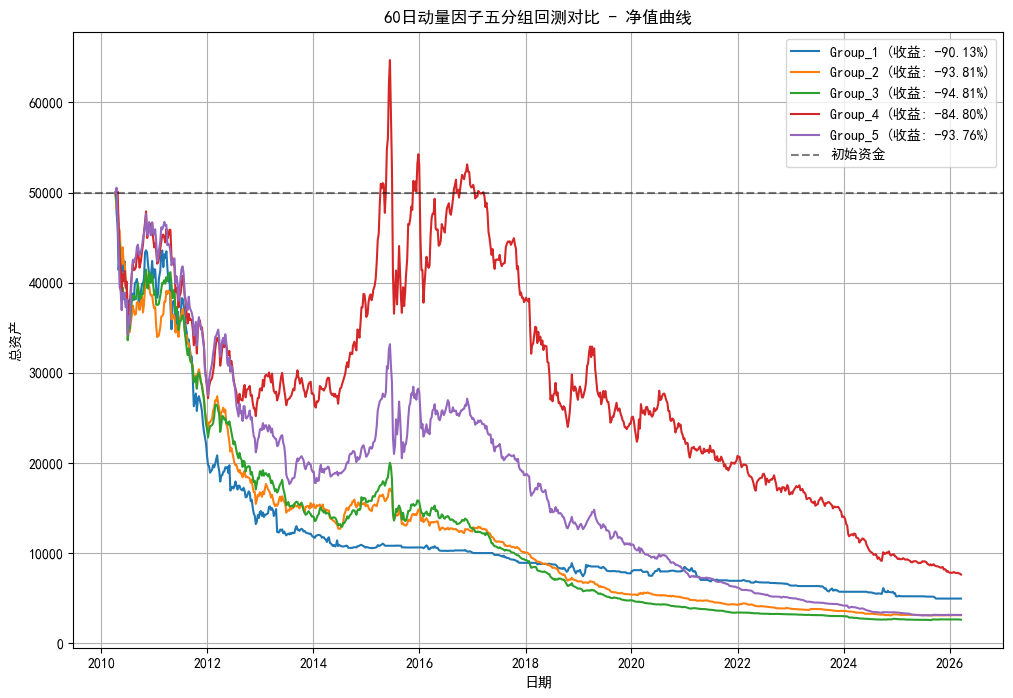

Group_1 (最高组) 交易明细已保存至: F:\self_quant\quant_gemini\csv\momentum_60d_trades_每周_Group1.csv


In [5]:
# ==========================================
# 五分组结果对比分析
# ==========================================
plt.figure(figsize=(12, 8))
all_summary = []

for group_name, account in accounts.items():
    df_assets = pd.DataFrame(account.history_assets).set_index('date')
    if df_assets.empty: continue
    final_asset = df_assets['total_asset'].iloc[-1]
    total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100
    
    # 统计前向收益
    buy_logs = pd.DataFrame(account.trade_logs)
    if not buy_logs.empty and '方向' in buy_logs.columns:
        buy_logs = buy_logs[buy_logs['方向'] == '买入']
    
    if not buy_logs.empty:
        stats = buy_logs[['未来1天收益', '未来1周收益', '未来1月收益']].mean() * 100
    else:
        stats = pd.Series({'未来1天收益': 0, '未来1周收益': 0, '未来1月收益': 0})
    
    all_summary.append({
        '分组': group_name,
        '最终资产': f"{final_asset:,.2f}",
        '总收益率': f"{total_return:.2f}%",
        '未来1天均值': f"{stats.get('未来1天收益', 0):.2f}%",
        '未来1周均值': f"{stats.get('未来1周收益', 0):.2f}%",
        '未来1月均值': f"{stats.get('未来1月收益', 0):.2f}%"
    })
    
    # 绘图
    plt.plot(df_assets.index, df_assets['total_asset'], label=f"{group_name} (收益: {total_return:.2f}%)")

if all_summary:
    print("\n--- 五分组回测对比摘要 ---")
    print(pd.DataFrame(all_summary))

plt.axhline(y=INITIAL_CASH, color='black', linestyle='--', alpha=0.5, label='初始资金')
plt.title("60日动量因子五分组回测对比 - 净值曲线")
plt.xlabel("日期")
plt.ylabel("总资产")
plt.legend()
plt.grid(True)
plt.show()

# 保存最高组交易明细
if accounts['Group_1'].trade_logs:
    top_group_trades = pd.DataFrame(accounts['Group_1'].trade_logs)
    csv_path = OUTPUT_CSV.replace('.csv', '_Group1.csv')
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    top_group_trades.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"Group_1 (最高组) 交易明细已保存至: {csv_path}")